In [1]:
import numpy as np
import pandas as pd

all_results_ddpg = np.load('all_results_DDPG.npy')
all_results_replace = np.load('all_results_replace.npy')
all_results_td3 = np.load('all_results_TD3.npy')

df1 = pd.read_csv('checkpoint_results_DDPG.csv')
df2 = pd.read_csv('checkpoint_results_replace.csv')
df3 = pd.read_csv('checkpoint_results_td3.csv')

In [2]:
def freturn_performance(all_results):
    final_angles = [results[:, 1] for results in all_results]
    maxdeg = 10
    maxrad = np.deg2rad(maxdeg)
    succes_rate = [len(results[:, 1][results[:, 1] < maxrad])/len(results[:, 1]) for results in all_results]
    return succes_rate

In [ ]:
sl_td3 = freturn_performance(all_results_td3)
sl_replace = freturn_performance(all_results_replace)
sl_ddpg = freturn_performance(all_results_ddpg)

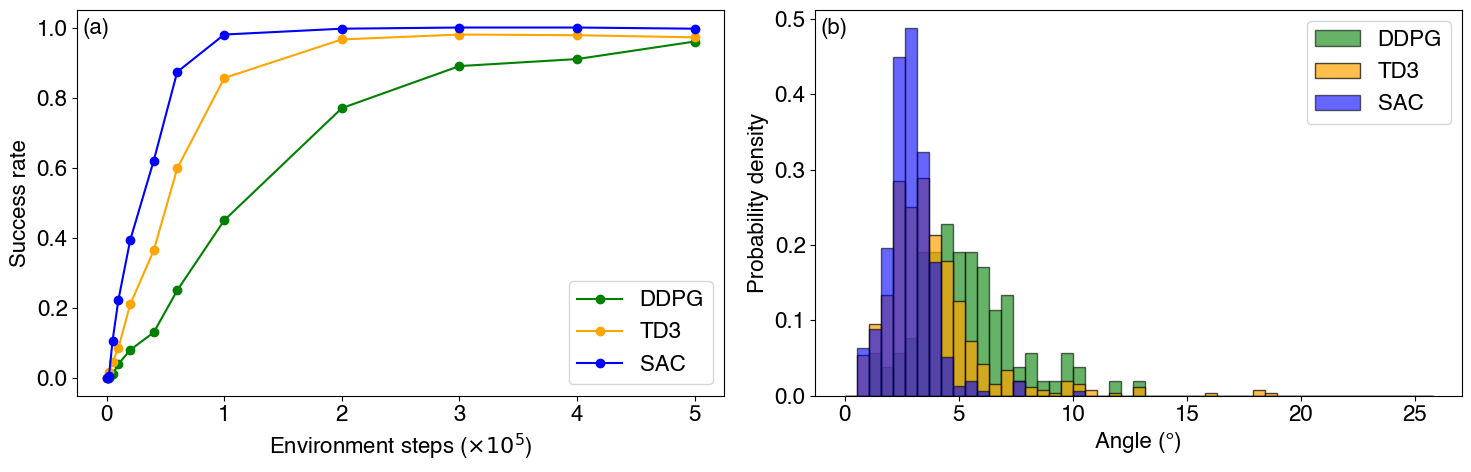

In [ ]:
import matplotlib.pyplot as plt
from matplotlib import font_manager
font_manager.fontManager.addfont("/home/tilen/.local/share/fonts/Helvetica.ttf")

# two figures side by side
fig, ax = plt.subplots(1, 2, figsize=(15, 5))

plt.rcParams.update({'font.size':16, 'axes.labelsize': 16})
plt.rcParams['font.family'] = 'Helvetica'

nsteps = 50

ax[0].plot(df1['step']/100000, np.array(sl_ddpg), marker='o', color='green', label='DDPG')
ax[0].plot(df3['step']/100000, np.array(sl_td3), marker='o', color='orange', label='TD3')
ax[0].plot(df2['step']/100000, np.array(sl_replace), marker='o', color='blue', label='SAC')
ax[0].set_xlabel('Environment steps ($\\times 10^5$)')
ax[0].set_ylabel('Success rate')


ax[0].set_xticks([0, 1, 2, 3, 4, 5])

ax[0].legend()

rad_to_deg = 180/np.pi
bins = np.linspace(0, 0.45*rad_to_deg, 50)

step = -1
ax[1].hist(all_results_ddpg[step][:, 1]*rad_to_deg, bins=bins, ec = 'black', density=True, color='green', alpha=0.6, label='DDPG')
ax[1].hist(all_results_td3[step][:, 1]*rad_to_deg, bins=bins, ec = 'black', density=True, color='orange', alpha=0.7, label='TD3')
ax[1].hist(all_results_replace[step][:, 1]*rad_to_deg, bins=bins, ec = 'black', density=True, color='blue', alpha=0.6, label='SAC')
ax[1].set_xlabel("Angle (°)")
ax[1].set_ylabel("Probability density")
ax[1].legend()

ax[0].text(
    0.0075, 0.98, '(a)',
    transform=ax[0].transAxes,
    ha='left', va='top',
    fontweight='bold',
    fontsize=16
)

ax[1].text(
    0.0075, 0.98, '(b)',
    transform=ax[1].transAxes,
    ha='left', va='top',
    fontweight='bold',
    fontsize=16
)

# save fig

plt.tight_layout()
plt.savefig('performance_comparison.png', dpi=300)